In [23]:
%load_ext autoreload
%autoreload 2

import os, ctypes
from glob import glob
append_ld_library_path = "~/.local/lib/python3.10/site-packages/nvidia/cublas/lib"
LD_LIBRARY_PATH = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = f"{append_ld_library_path}:{LD_LIBRARY_PATH}" if LD_LIBRARY_PATH else append_ld_library_path

cublas_dir = "/home/ubuntu/.local/lib/python3.10/site-packages/nvidia/cublas/lib"
for pat in ["libcublas.so*", "libcublasLt.so*", "libcudart.so*"]:
    for lib in sorted(glob(os.path.join(cublas_dir, pat))):
        try:
            ctypes.CDLL(lib, mode=ctypes.RTLD_GLOBAL)
        except OSError as e:
            print(f"Warning: could not load {lib}: {e}")

import torch
import torch._dynamo
torch._dynamo.config.suppress_errors = True

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MaxNLocator

import os
import pickle
from tqdm import tqdm
from glob import glob
from copy import deepcopy

from sklearn.decomposition import PCA

from MSA_Pairformer.model import MSAPairformer
from MSA_Pairformer.dataset import MSA, aa2tok_d, prepare_msa_masks

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
torch.set_float32_matmul_precision('high')
print(f"Using device: {torch.cuda.get_device_name(device)}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: NVIDIA GH200 480GB


In [2]:
# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
msa_pairformer = MSAPairformer.from_pretrained(
    device=device
)
msa_pairformer.eval()
print(f"Using device: {torch.cuda.get_device_name(device)}")

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Using cuEquivariance for triangle multiplicative update
Using device: NVIDIA GH200 480GB


# Predict contacts and query-bias sequence weights for response regulator sequences

In [20]:
msa_file_path = "../../data/Figure4/subset_filtered_PF00072.a3m"
msa_depth = 4096
seqid2subfamily_d = pickle.load(open("../../data/Figure4/seqid2subfamily.pkl", "rb"))
subfamily_l = set(seqid2subfamily_d.values())
alignment_seq_d = pickle.load(open("../../data/Figure4/pdb2alignment_seqs.pkl", "rb"))
subfamily2pdb_d = {"OmpR": "1NXS", "LytTR": "4CBV", "GerE": "4E7P"}

# Output directory
out_dir = "results/"
res_d = {}

# Load MSA
# # If you want to subset from the full MSA, you can do so here
# np.random.seed(0)
# hhfilter_kwargs = dict(
#     seq_id = 90,
#     cov = 70,
#     qid = 15
# )
# msa_obj = MSA(
#     msa_file_path = msa_file_path,
#     max_seqs=msa_depth,
#     diverse_select_method="hhfilter",
#     hhfilter_kwargs=hhfilter_kwargs,
#     secondary_filter_method="random"
# )
# tokenized_seq_a = msa_obj.diverse_tokenized_msa
# Get subfamily labels for MSA
# msa_subfamily_l = [seqid2subfamily_d[msa_obj.ids_l[idx]] for idx in msa_obj.select_diverse_indices]

# For reproducibility, we load the same MSA used in the paper
msa_file_path = "../../data/Figure4/subsampled_rr_msa.a3m"
with open(msa_file_path, "r") as f:
    msa_lines_l = f.readlines()
    seq_l = [line.strip() for line in msa_lines_l[1::2] if line.strip()]
    seq_a = np.array([list(s) for s in seq_l])
    tokenized_seq_a = np.vectorize(aa2tok_d.get)(seq_a)
    seq_ids_l = [l[1:].strip() for l in msa_lines_l[::2]]
    msa_subfamily_l = [seqid2subfamily_d[seq_id] for seq_id in seq_ids_l]

# Iterate over all 3 subfamilies. Add query sequence for each subfamily to bias contacts
for subfamily in tqdm(subfamily_l):
    # Get subfamily labels for MSA
    msa_subfamily_members_l = [True] + [subfamily == curr_subfamily for curr_subfamily in msa_subfamily_l]
    msa_non_subfamily_members_l = [False] + [subfamily != curr_subfamily for curr_subfamily in msa_subfamily_l]
    # Add subfamily sequence to MSA
    full_tokenized_msa_a = deepcopy(tokenized_seq_a)
    subfamily_seq = np.array(list(alignment_seq_d[subfamily2pdb_d[subfamily]]))
    tokenized_subfamily_seq = np.vectorize(aa2tok_d.get)(subfamily_seq)
    full_tokenized_msa_a = torch.from_numpy(np.concatenate([tokenized_subfamily_seq[None, :], full_tokenized_msa_a]))
    msa_onehot_t = torch.nn.functional.one_hot(full_tokenized_msa_a, num_classes=len(aa2tok_d)).unsqueeze(0).to(device)
    msa_onehot_t = msa_onehot_t.float()
    mask, msa_mask, full_mask, pairwise_mask = prepare_msa_masks(full_tokenized_msa_a.unsqueeze(0))
    mask = mask.to(device)
    msa_mask = msa_mask.to(device)
    full_mask = full_mask.to(device)
    pairwise_mask = pairwise_mask.to(device)
    # Run forward pass
    with torch.no_grad():
        with torch.amp.autocast(device_type=device.type, dtype=torch.bfloat16):
            msa_pairformer.turn_off_query_biasing()
            uniform_res = msa_pairformer(
                msa = msa_onehot_t, 
                mask = mask, 
                msa_mask = msa_mask, 
                full_mask = full_mask, 
                pairwise_mask = pairwise_mask,
                return_seq_weights = True,
                return_cb_contacts = True
            )
            msa_pairformer.turn_on_query_biasing()
            qba_res = msa_pairformer(
                msa = msa_onehot_t, 
                mask = mask, 
                msa_mask = msa_mask, 
                full_mask = full_mask, 
                pairwise_mask = pairwise_mask,
                return_seq_weights = True,
                return_cb_contacts = True
            )
    # Get contacts
    uniform_contacts_t = uniform_res['predicted_cb_contacts'][0].float().cpu().numpy()
    qba_contacts_t = qba_res['predicted_cb_contacts'][0].float().cpu().numpy()
    # Get mean sequence weights for subfamily and non-subfamily sequences
    subfamily_mean_seq_weights_a = [qba_res['seq_weights_list_d'][layer][0, msa_subfamily_members_l].cpu().numpy() for layer in qba_res['seq_weights_list_d']]
    non_subfamily_mean_seq_weights_a = [qba_res['seq_weights_list_d'][layer][0, msa_non_subfamily_members_l].cpu().numpy() for layer in qba_res['seq_weights_list_d']]
    all_weights_a = [qba_res['seq_weights_list_d'][layer][0].cpu().numpy() for layer in qba_res['seq_weights_list_d']]
    # Compute hamming distance between all sequences to the query sequence
    hamming_dist_a = (torch.sum(full_tokenized_msa_a != full_tokenized_msa_a[0], dim=-1) / full_tokenized_msa_a.shape[1]).numpy()
    # Store results
    res_d[subfamily] = {}
    res_d[subfamily]['uniform_contacts'] = uniform_contacts_t
    res_d[subfamily]['qba_contacts'] = qba_contacts_t
    res_d[subfamily]['sequence_weights'] = {'Subfamily': subfamily_mean_seq_weights_a, 'Non-subfamily': non_subfamily_mean_seq_weights_a, 'All': all_weights_a}
    res_d[subfamily]['hamming_dist'] = hamming_dist_a
    res_d[subfamily]['subfamily_labels'] = msa_subfamily_l
results_file = os.path.join(out_dir, "response_regulator_results.pkl")
with open(results_file, "wb") as f:
    pickle.dump(res_d, f)
print("Sequence counts: ")
print(np.unique(msa_subfamily_l, return_counts=True))

100%|██████████| 3/3 [00:05<00:00,  1.69s/it]

Sequence counts: 
(array(['GerE', 'LytTR', 'OmpR'], dtype='<U5'), array([2506, 1074,  516]))


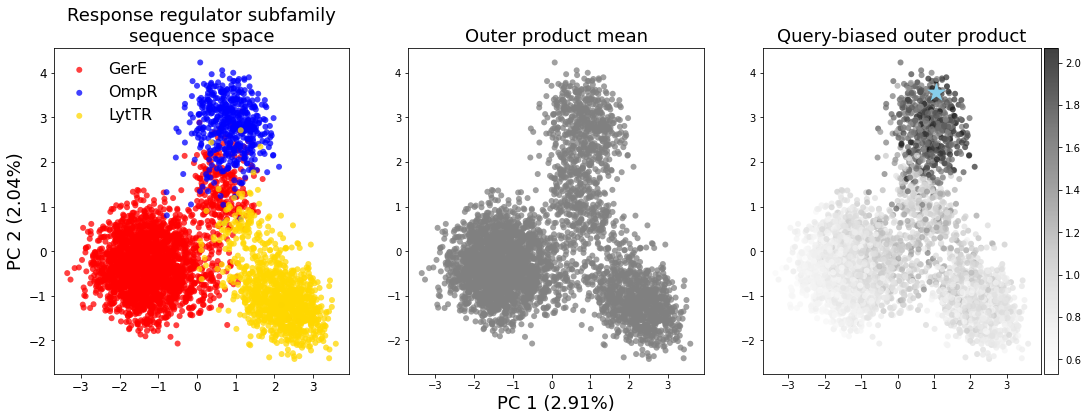

In [21]:
msa_file_path = "../../data/Figure4/subset_filtered_PF00072.a3m"
msa_depth = 4096
seqid2subfamily_d = pickle.load(open("../../data/Figure4/seqid2subfamily.pkl", "rb"))
subfamily_l = set(seqid2subfamily_d.values())
alignment_seq_d = pickle.load(open("../../data/Figure4/pdb2alignment_seqs.pkl", "rb"))
subfamily2pdb_d = {"OmpR": "1NXS", "LytTR": "4CBV", "GerE": "4E7P"}

msa_file_path = "../../data/Figure4/subsampled_rr_msa.a3m"
with open(msa_file_path, "r") as f:
    msa_lines_l = f.readlines()
    seq_l = [line.strip() for line in msa_lines_l[1::2] if line.strip()]
    seq_a = np.array([list(s) for s in seq_l])
    tokenized_seq_a = np.vectorize(aa2tok_d.get)(seq_a)
    seq_ids_l = [l[1:].strip() for l in msa_lines_l[::2]]
    msa_subfamily_l = [seqid2subfamily_d[seq_id] for seq_id in seq_ids_l]

# # Store results for depth
plot_subfamily = 'OmpR'
# Get subfamily labels for MSA
msa_subfamily_members_l = [True] + [plot_subfamily == curr_subfamily for curr_subfamily in msa_subfamily_l]
msa_non_subfamily_members_l = [False] + [plot_subfamily != curr_subfamily for curr_subfamily in msa_subfamily_l]
# Add subfamily sequence to MSA
full_tokenized_msa_a = deepcopy(tokenized_seq_a)
subfamily_seq = np.array(list(alignment_seq_d[subfamily2pdb_d[plot_subfamily]]))
tokenized_subfamily_seq = np.vectorize(aa2tok_d.get)(subfamily_seq)
full_tokenized_msa_a = torch.from_numpy(np.concatenate([tokenized_subfamily_seq[None, :], full_tokenized_msa_a]))
msa_onehot_t = torch.nn.functional.one_hot(full_tokenized_msa_a, num_classes=len(aa2tok_d)).unsqueeze(0)

# One-hot encode all sequences
ohe_vecs = msa_onehot_t.float().reshape(-1, len(aa2tok_d) * msa_onehot_t.shape[2]).numpy()
ohe_vecs = ohe_vecs.astype(np.float32)
mdl = PCA()
embedding = mdl.fit_transform(ohe_vecs)
explained_variance = mdl.explained_variance_ratio_ * 100
# Plot PCA
f, ax = plt.subplots(1, 3, figsize=(18,6))
subfamily_cmap_d = {"GerE": "red", "OmpR": "blue", "LytTR": "gold"}
med_seq_weights_a = np.median(np.stack(res_d[plot_subfamily]['sequence_weights']['All']), axis=0)
med_seq_weights_a *= med_seq_weights_a.shape[0]
for subfamily, color in subfamily_cmap_d.items():
    # mask = [seqid2subfamily_d[seqid] == subfamily for seqid in ompr_msa_obj.ids_l]
    mask = [subfamily == plot_subfamily] + [msa_subfamily_l[idx] == subfamily for idx in range(len(msa_subfamily_l))]
    ax[0].scatter(embedding[mask, 0], embedding[mask, 1], 
              alpha=0.75, c=color, label=subfamily, edgecolor='none', rasterized=True)
ax[0].legend(bbox_to_anchor=(0.4,1), frameon=False, fontsize=16)
ax[1].set_xlabel(f"PC 1 ({explained_variance[0]:.2f}%)", size = 18)
ax[0].set_ylabel(f"PC 2 ({explained_variance[1]:.2f}%)", size = 18)
ax[0].set_title("Response regulator subfamily\nsequence space", size = 18)
ax[0].tick_params(axis='both', which='major', labelsize=12)
ax[1].scatter(embedding[:, 0], embedding[:, 1], 
              alpha=0.75, c="grey", edgecolor='none', rasterized=True)
ax[1].set_title("Outer product mean", size = 18)
im = ax[2].scatter(embedding[1:, 0], embedding[1:, 1], 
                   alpha=0.75, c=med_seq_weights_a[1:], cmap='Greys', edgecolor='none', rasterized=True)
ax[2].scatter(embedding[0, 0], embedding[0, 1], marker='*', s=400, c='skyblue', edgecolors='none', rasterized=True)
ax[2].set_title("Query-biased outer product", size=18)
divider = make_axes_locatable(ax[2])
cax = divider.append_axes("right", size="5%", pad=0.05)
f.colorbar(im, cax=cax)

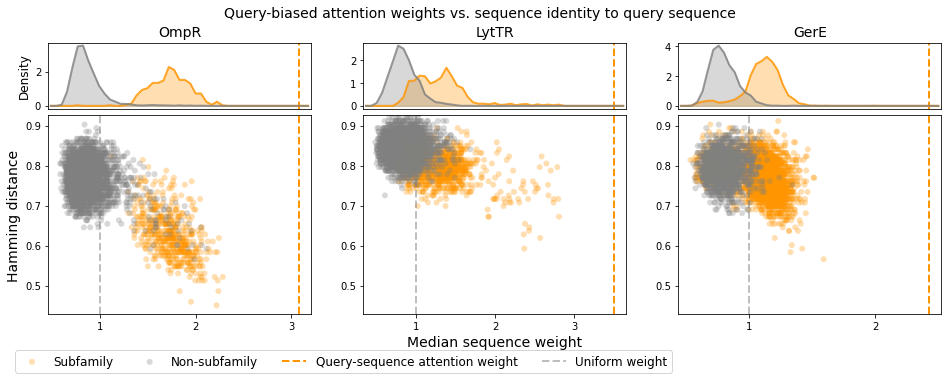

In [22]:
with open("results/response_regulator_results.pkl", "rb") as f:
    res_d = pickle.load(f)
msa_depth = 4096
# Create a custom grid layout with histogram space above each scatter plot
fig = plt.figure(figsize=(16, 5))
gs = GridSpec(2, 3, height_ratios=[1, 3], hspace=0.05)

# Create subplots for histograms (top row) and scatter plots (bottom row)
hist_axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
scatter_axes = [fig.add_subplot(gs[1, i]) for i in range(3)]

# Color for subfamily dots and distribution
subfamily_color = "#FF9500"

# for idx, subfamily in enumerate(subfamily_l):
for idx, subfamily in enumerate(["OmpR", "LytTR", "GerE"]):
    avg_seq_weights_a = np.median(np.stack([res_d[subfamily]['sequence_weights']['All'][i] for i in range(16)]), axis=0)
    hamming_dist_a = res_d[subfamily]['hamming_dist']
    
    # Get indices for subfamily and non-subfamily points
    subfamily_idx_l = np.array([i+1 for i in range(len(res_d[subfamily]['subfamily_labels'])) if res_d[subfamily]['subfamily_labels'][i] == subfamily])
    non_subfamily_idx_l = np.array([i+1 for i in range(len(res_d[subfamily]['subfamily_labels'])) if res_d[subfamily]['subfamily_labels'][i] != subfamily])
    
    # Plot scatter points first to establish proper axis limits
    scatter_axes[idx].scatter(avg_seq_weights_a[subfamily_idx_l] * msa_depth, hamming_dist_a[subfamily_idx_l], 
                             c=subfamily_color, label='Subfamily', alpha=0.3, edgecolors="none", rasterized=True)
    scatter_axes[idx].scatter(avg_seq_weights_a[non_subfamily_idx_l] * msa_depth, hamming_dist_a[non_subfamily_idx_l], 
                             c='grey', label='Non-subfamily', alpha=0.3, edgecolors="none", rasterized=True)

    # Add vertical line for query sequence weight
    query_weight = avg_seq_weights_a[0] * msa_depth
    hist_axes[idx].axvline(x=query_weight, linestyle='--', color=subfamily_color, linewidth=2)
    scatter_axes[idx].axvline(x=query_weight, linestyle='--', color=subfamily_color, 
                             label='Query-sequence attention weight', linewidth=2)
    
    # Get the x-axis limits from the scatter plot
    x_min, x_max = scatter_axes[idx].get_xlim()
    x_max = max(x_max, query_weight)
    
    # Create histogram curves for sequence weights
    weights_subfamily = avg_seq_weights_a[subfamily_idx_l] * msa_depth
    weights_non_subfamily = avg_seq_weights_a[non_subfamily_idx_l] * msa_depth
    
    # Calculate histograms with proper range
    bins = np.linspace(x_min, x_max, 50)
    hist_subfamily, _ = np.histogram(weights_subfamily, bins=bins, density=True)
    hist_non_subfamily, _ = np.histogram(weights_non_subfamily, bins=bins, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Plot histogram curves
    hist_axes[idx].plot(bin_centers, hist_subfamily, color=subfamily_color, linewidth=2, label='Subfamily', alpha=0.8)
    hist_axes[idx].plot(bin_centers, hist_non_subfamily, color='grey', linewidth=2, label='Non-subfamily', alpha=0.8)
    hist_axes[idx].fill_between(bin_centers, hist_subfamily, alpha=0.3, color=subfamily_color)
    hist_axes[idx].fill_between(bin_centers, hist_non_subfamily, alpha=0.3, color='grey')
    
    # Set the same x-limits for both histogram and scatter plot
    hist_axes[idx].set_xlim(x_min, x_max)
    scatter_axes[idx].set_xlim(x_min, x_max)
    
    # Format histogram axes
    hist_axes[idx].set_title(subfamily, size=14)
    hist_axes[idx].set_xticks([])  # Remove x-axis ticks from histogram
    if idx == 0:
        hist_axes[idx].set_ylabel('Density', size=12)

    # Add grey dotted line at x = 1
    scatter_axes[idx].axvline(x=1, linestyle='--', color='grey', linewidth=2, alpha=0.5, label="Uniform weight")
    
    # Format scatter axes
    scatter_axes[idx].xaxis.set_major_locator(plt.MaxNLocator(4))
    if idx == 2:
        # scatter_axes[idx].legend(fontsize=12, bbox_to_anchor=(-0.5, -0.15), ncol=4)
        scatter_axes[idx].legend(fontsize=12, bbox_to_anchor=(0, -0.15), ncol=4)

# Set labels
scatter_axes[1].set_xlabel("Median sequence weight", size=14)
scatter_axes[0].set_ylabel("Hamming distance", size=14)
fig.suptitle("Query-biased attention weights vs. sequence identity to query sequence", size=14)

# Share y-axis for scatter plots
for i in range(1, 3):
    scatter_axes[i].sharey(scatter_axes[0])
# Set x-ticks
scatter_axes[0].set_xticks([1, 2, 3])
scatter_axes[1].set_xticks([1, 2, 3])
scatter_axes[2].set_xticks([1, 2])

# 2. Plot contacts

In [27]:
# Load results
with open("results/response_regulator_results.pkl", "rb") as f:
    data = pickle.load(f)

# load npy file 
truth_dir = '../../data/Figure4/contact_matrices'
inter_contact_1nxs = np.load(os.path.join(truth_dir, 'aligned_1NXS-assembly1_inter.npy'))
inter_contact_4cbv = np.load(os.path.join(truth_dir, 'aligned_4CBV-assembly1_inter.npy'))
inter_contact_4e7p = np.load(os.path.join(truth_dir, 'aligned_4E7P-assembly2_inter.npy'))
intra_contact_1nxs = np.load(os.path.join(truth_dir, 'aligned_1NXS-assembly1_intra.npy'))
intra_contact_4cbv = np.load(os.path.join(truth_dir, 'aligned_4CBV-assembly1_intra.npy'))
intra_contact_4e7p = np.load(os.path.join(truth_dir, 'aligned_4E7P-assembly2_intra.npy'))
all_contact_1nxs = np.load(os.path.join(truth_dir, 'aligned_1NXS-assembly1_all.npy'))
all_contact_4cbv = np.load(os.path.join(truth_dir, 'aligned_4CBV-assembly1_all.npy'))
all_contact_4e7p = np.load(os.path.join(truth_dir, 'aligned_4E7P-assembly2_all.npy'))

In [28]:
def get_top_L_indices(pred_contacts, cutoff_res_sep, total_contacts):
    indices = [(i, j) for i in range(len(pred_contacts)) for j in range(i + cutoff_res_sep, len(pred_contacts))]
    pred_values = [pred_contacts[i, j] for i, j in indices]
    top_L_flat_indices = np.argsort(pred_values)[-total_contacts:]
    top_L_indices = [indices[i] for i in top_L_flat_indices]
    return top_L_indices

def get_exp_contact_indices(contact, cutoff_res_sep):
    return [(i, j) for i in range(len(contact)) for j in range(i + cutoff_res_sep, len(contact)) if contact[i, j] == 1]

def plot_contact_map_combined_triangle(
    predicted_contact,
    family1_indices,
    family2_indices,
    family3_indices,
    model_name,
    cutoff_res_sep, #6
    top_range,
    ax = None, 
    fig = None
):
    n = predicted_contact.shape[0]

    # Upper triangle matrix for imshow
    upper = np.full((n, n), np.nan)
    upper_i, upper_j = [], []
    upper_values = []
    for i in range(n):
        for j in range(i, n):  # i <= j
            upper[i, j] = predicted_contact[i, j]
            upper_i.append(i)
            upper_j.append(j)
            upper_values.append(predicted_contact[i, j])

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(upper, origin='upper', cmap='viridis', vmin=0, vmax=1, interpolation='none')

    # Lower triangle: top-L predictions
    indices = [(i, j) for i in range(n) for j in range(i + cutoff_res_sep, n)]
    scores = [predicted_contact[i, j] for i, j in indices]
    top_L_indices = [indices[k] for k in np.argsort(scores)[-top_range:]]
    top_L_indices = np.array(top_L_indices)

    contact_data = []

    # Plot and collect annotated points
    ax.scatter(top_L_indices[:, 0], top_L_indices[:, 1], s=5, c='gray', rasterized=True)

    for i, j in top_L_indices:
        score = predicted_contact[i, j]
        if (i, j) in family1_indices:
            ax.scatter(i, j, s=10, c='blue', rasterized=True)
            contact_data.append({'type': 'OmpR-1NXS', 'i': i, 'j': j, 'value': score})
        if (i, j) in family2_indices:
            ax.scatter(i, j, s=10, c='orange', rasterized=True)
            contact_data.append({'type': 'LytTR-4CBV', 'i': i, 'j': j, 'value': score})
        if (i, j) in family3_indices:
            ax.scatter(i, j, s=10, c='red', rasterized=True)
            contact_data.append({'type': 'GerE-4E7P', 'i': i, 'j': j, 'value': score})

    ax.set_xlim(0, n-1)
    ax.set_ylim(n-1, 0)
    ax.set_aspect('equal')
    ax.set_title(model_name)
    fig.tight_layout()

    # Save contact data to CSV
    df = pd.DataFrame(contact_data)
    df_sorted = df.sort_values(by='value', ascending=False)

    return df_sorted, f, ax

In [32]:
cutoff_res_sep = 6
inter_1nxs_indices = get_exp_contact_indices(inter_contact_1nxs, cutoff_res_sep)
inter_4cbv_indices = get_exp_contact_indices(inter_contact_4cbv, cutoff_res_sep)
inter_4e7p_indices = get_exp_contact_indices(inter_contact_4e7p, cutoff_res_sep)
all_1nxs_indices = get_exp_contact_indices(all_contact_1nxs, cutoff_res_sep)
all_4cbv_indices = get_exp_contact_indices(all_contact_4cbv, cutoff_res_sep)
all_4e7p_indices = get_exp_contact_indices(all_contact_4e7p, cutoff_res_sep)

In [30]:
stats_df = pd.DataFrame(columns=['Prediction type', 'Interface contact subfamily', 'Interface contact', 'Contact prediction'])
stats_s_l = []
for i, j in inter_1nxs_indices:
    stats_s_l.append([
        pd.Series([
            'Uniform sequence weighting', 
            'OmpR-1NXS', 
            f"({i}, {j})",
            data['GerE']['uniform_contacts'][i, j]
        ]),
        
    ])
    stats_s_l.append([
        pd.Series([
            'OmpR QBA', 
            'OmpR-1NXS', 
            f"({i}, {j})",
            data['OmpR']['qba_contacts'][i, j]
        ]),
        
    ])
    stats_s_l.append([
        pd.Series([
            'LytTR QBA', 
            'OmpR-1NXS', 
            f"({i}, {j})",
            data['LytTR']['qba_contacts'][i, j]
        ]),  
    ])
    stats_s_l.append([
        pd.Series([
            'GerE QBA', 
            'OmpR-1NXS', 
            f"({i}, {j})",
            data['GerE']['qba_contacts'][i, j]
        ]),
    ])
for i, j in inter_4cbv_indices:
    stats_s_l.append([
        pd.Series([
            'Uniform sequence weighting', 
            'LytTR-4CBV', 
            f"({i}, {j})",
            data['GerE']['uniform_contacts'][i, j]
        ]),
        
    ])
    stats_s_l.append([
        pd.Series([
            'OmpR QBA', 
            'LytTR-4CBV', 
            f"({i}, {j})",
            data['OmpR']['qba_contacts'][i, j]
        ]),
        
    ])
    stats_s_l.append([
        pd.Series([
            'LytTR QBA', 
            'LytTR-4CBV', 
            f"({i}, {j})",
            data['LytTR']['qba_contacts'][i, j]
        ]),  
    ])
    stats_s_l.append([
        pd.Series([
            'GerE QBA', 
            'LytTR-4CBV', 
            f"({i}, {j})",
            data['GerE']['qba_contacts'][i, j]
        ]),
    ])
for i, j in inter_4e7p_indices:
    stats_s_l.append([
        pd.Series([
            'Uniform sequence weighting', 
            'GerE-4E7P', 
            f"({i}, {j})",
            data['GerE']['uniform_contacts'][i, j]
        ]),
        
    ])
    stats_s_l.append([
        pd.Series([
            'OmpR QBA', 
            'GerE-4E7P', 
            f"({i}, {j})",
            data['OmpR']['qba_contacts'][i, j]
        ]),
        
    ])
    stats_s_l.append([
        pd.Series([
            'LytTR QBA', 
            'GerE-4E7P', 
            f"({i}, {j})",
            data['LytTR']['qba_contacts'][i, j]
        ]),  
    ])
    stats_s_l.append([
        pd.Series([
            'GerE QBA', 
            'GerE-4E7P', 
            f"({i}, {j})",
            data['GerE']['qba_contacts'][i, j]
        ]),
    ])
# Flatten the list of lists and concatenate into a single DataFrame
stats_df = pd.concat([s[0] for s in stats_s_l], axis=1).T
stats_df.columns = ['Prediction type', 'Interface contact subfamily', 'Interface contact', 'contact prediction']
stats_df.reset_index(drop=True, inplace=True)
stats_df

,Prediction type,Interface contact subfamily,Interface contact,contact prediction
0,Uniform sequence weighting,OmpR-1NXS,"(83, 103)",0.007341
1,OmpR QBA,OmpR-1NXS,"(83, 103)",0.469605
2,LytTR QBA,OmpR-1NXS,"(83, 103)",0.012374
3,GerE QBA,OmpR-1NXS,"(83, 103)",0.002278
4,Uniform sequence weighting,OmpR-1NXS,"(83, 105)",0.002403
...,...,...,...,...
191,GerE QBA,GerE-4E7P,"(15, 105)",0.001447
192,Uniform sequence weighting,GerE-4E7P,"(30, 103)",0.000464
193,OmpR QBA,GerE-4E7P,"(30, 103)",0.000189
194,LytTR QBA,GerE-4E7P,"(30, 103)",0.000281


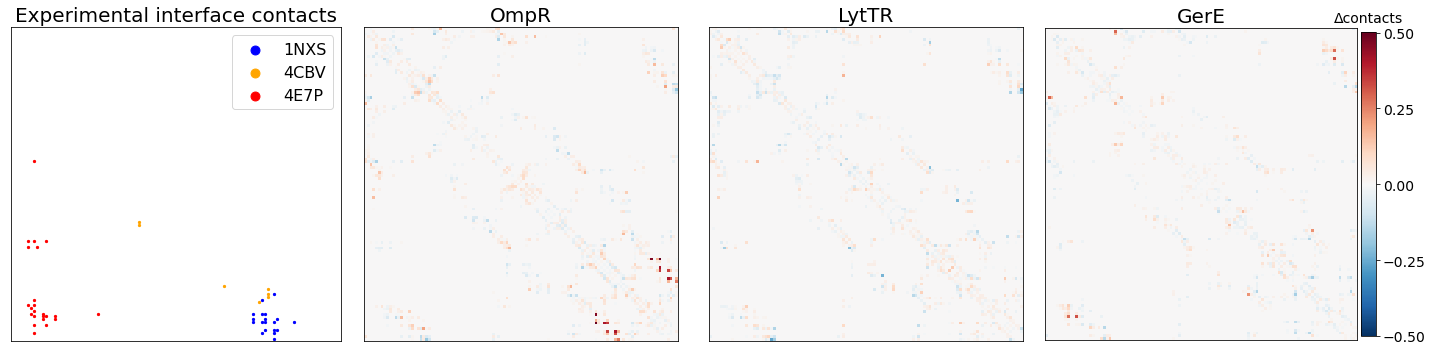

In [ ]:
f, ax = plt.subplots(1, 4, figsize=(20, 5))

##### Ground truth contacts #####
ax[0].scatter([i for i, j in inter_1nxs_indices], [j for i, j in inter_1nxs_indices], s=5, c='blue', label='1NXS')
ax[0].scatter([i for i, j in inter_4cbv_indices], [j for i, j in inter_4cbv_indices], s=5, c='orange', label='4CBV')
ax[0].scatter([i for i, j in inter_4e7p_indices], [j for i, j in inter_4e7p_indices], s=5, c='red', label='4E7P')
ax[0].set_xlim(0, len(inter_contact_1nxs))
ax[0].set_ylim(len(inter_contact_1nxs), 0)
ax[0].legend(fontsize=16, markerscale=4)
ax[0].set_title("Experimental interface contacts", size=20)

# Calculate the min and max values across all three difference maps for consistent color scale
dist_mask = np.ones((data['OmpR']['qba_contacts'].shape[0], data['OmpR']['qba_contacts'].shape[0]))
for i in range(data['OmpR']['qba_contacts'].shape[0]):
    for j in range(i, data['OmpR']['qba_contacts'].shape[0]):
        if j - i < 6:
            dist_mask[i, j] = 0
            dist_mask[j, i] = 0
vmin = min(
    np.min((data['OmpR']['qba_contacts'] - data['OmpR']['uniform_contacts'])[np.where(dist_mask)]),
    np.min((data['LytTR']['qba_contacts'] - data['LytTR']['uniform_contacts'])[np.where(dist_mask)]),
    np.min((data['GerE']['qba_contacts'] - data['GerE']['uniform_contacts'])[np.where(dist_mask)])
)
vmax = max(
    np.max((data['OmpR']['qba_contacts'] - data['OmpR']['uniform_contacts'])[np.where(dist_mask)]),
    np.max((data['LytTR']['qba_contacts'] - data['LytTR']['uniform_contacts'])[np.where(dist_mask)]),
    np.max((data['GerE']['qba_contacts'] - data['GerE']['uniform_contacts'])[np.where(dist_mask)])
)
vmin = -1 * max(abs(vmin), abs(vmax))
vmax = 1 * max(abs(vmin), abs(vmax))
delta_a = data['OmpR']['qba_contacts'] - data['OmpR']['uniform_contacts']
delta_a[np.where(np.abs(delta_a) < 0.01)] = 0
im1 = ax[1].imshow(delta_a, rasterized=True, interpolation='none', vmin=vmin, vmax=vmax, cmap='RdBu_r')
ax[1].set_title("OmpR", size=20)

delta_a = data['LytTR']['qba_contacts'] - data['LytTR']['uniform_contacts']
delta_a[np.where(np.abs(delta_a) < 0.01)] = 0
im2 = ax[2].imshow(delta_a, rasterized=True, interpolation='none', vmin=vmin, vmax=vmax, cmap='RdBu_r')
ax[2].set_title("LytTR", size=20)

delta_a = data['GerE']['qba_contacts'] - data['GerE']['uniform_contacts']
delta_a[np.where(np.abs(delta_a) < 0.01)] = 0
im3 = ax[3].imshow(delta_a, rasterized=True, interpolation='none', vmin=vmin, vmax=vmax, cmap='RdBu_r')
ax[3].set_title("GerE", size=20)
cbar3 = f.colorbar(im3, ax=ax[3], fraction=0.046, pad=0.01)
cbar3.ax.tick_params(labelsize=14)
cbar3.locator = MaxNLocator(nbins=5)
cbar3.update_ticks()
cbar3.ax.set_title("Δcontacts", fontsize=14, pad=10)
# Remove all y-axis and x-axis ticks
for j in range(4):
    ax[j].set_xticks([])
    ax[j].set_yticks([])
f.tight_layout()

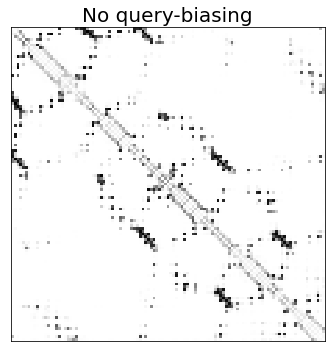

In [34]:
f, ax = plt.subplots(1, 1, figsize=(5, 5), facecolor='white')
ax.imshow(data['GerE']['uniform_contacts'], cmap='Greys', interpolation='none', rasterized=True)
ax.set_title("No query-biasing", size=20)
ax.set_xticks([])
ax.set_yticks([])
f.tight_layout()